<h1>Crop Yield Prediction in Nepal using Machine Learning</h1>

<h2>Importing all the necessary libraries</h2>

In [4]:
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For advanced visualizations
from sklearn.model_selection import train_test_split, GridSearchCV, KFold  # For splitting data and tuning models
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # For encoding categories and scaling features
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For evaluating model performance
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Linear models
from sklearn.tree import DecisionTreeRegressor  # Tree model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor  # Ensemble models
from sklearn.svm import SVR  # Support Vector Regressor
from xgboost import XGBRegressor  # XGBoost model
from lightgbm import LGBMRegressor  # LightGBM model
from catboost import CatBoostRegressor  # CatBoost model
from sklearn.feature_selection import SelectKBest, f_regression  # Feature selection
from statsmodels.stats.outliers_influence import variance_inflation_factor  # For VIF
import time  # For measuring time
import os  # For creating folders
import joblib  # For saving models

<h3>Create 'plots' folder if it doesn't exist</h3>

In [5]:
if not os.path.exists('plots'):
    os.makedirs('plots')
print("Plots folder created or already exist.")

Plots folder created or already exist.


<h3>Load the dataset</h3>

In [6]:
crop_data = pd.read_csv("../data/cleaned_dataset_for_ml.csv", index_col=0)  # Load CSV; index_col=0 if year is unnamed
print("Dataset loaded. First few rows:")
print(crop_data.head())  # Show first rows

Dataset loaded. First few rows:
     Districts     Area  yield_kg/ha crop_type  avg_temp_C  max_temp_C  \
Year                                                                     
2067    Achham   9450.0       2400.0     Paddy   13.058082   18.971014   
2067    Achham   6351.0       1550.0     Maize   13.058082   18.971014   
2067    Achham   3412.0        950.0    Millet   13.058082   18.971014   
2067    Achham  16139.0       1450.0     Wheat   13.058082   18.971014   
2067    Achham    514.0       1298.0    Barley   13.058082   18.971014   

      min_temp_C  avg_relative_humidity  avg_rainfall_mm_per_year  \
Year                                                                
2067     8.11411               61.27663                   1245.93   
2067     8.11411               61.27663                   1245.93   
2067     8.11411               61.27663                   1245.93   
2067     8.11411               61.27663                   1245.93   
2067     8.11411               61.2

<h3>Description of Datasets</h3>

In [7]:
print("Dataset shape (rows, columns):", crop_data.shape)  # Show size
print("Dataset columns:", crop_data.columns.tolist())  # Show column names
print("Dataset statistics:")
print(crop_data.describe())  # Show summary stats

Dataset shape (rows, columns): (5155, 14)
Dataset columns: ['Districts', 'Area', 'yield_kg/ha', 'crop_type', 'avg_temp_C', 'max_temp_C', 'min_temp_C', 'avg_relative_humidity', 'avg_rainfall_mm_per_year', 'total_solar_radiation_kWh/m2', 'total_PAR_MJ/m2', 'avg_wind_speed_m/s', 'avg_pH_value', 'fertilizer_in_MT']
Dataset statistics:
               Area    yield_kg/ha   avg_temp_C   max_temp_C   min_temp_C  \
count   5155.000000    5155.000000  5155.000000  5155.000000  5155.000000   
mean    8421.835083    2084.296769    16.270837    21.721406    11.933885   
std    12926.983257    1747.449650     6.872109     6.967467     6.829374   
min        0.910215     103.000000    -2.113443     4.066257    -7.292596   
25%      300.000000    1135.000000    10.704356    16.246767     6.279699   
50%     3476.000000    1860.000000    18.543562    23.487616    14.851014   
75%    11686.000000    2800.000000    22.046493    27.778247    17.637397   
max    93364.000000  101250.000000    26.605929    

<h3>Handle missing values, duplicates, and outliers</h3>

In [8]:
crop_data = crop_data.dropna()  # Remove rows with missing values
crop_data.drop_duplicates(inplace=True)  # Remove duplicate rows

<h3>Outlier handling for yield_kg/ha using IQR</h3>

In [9]:
Q1 = crop_data['yield_kg/ha'].quantile(0.25)
Q3 = crop_data['yield_kg/ha'].quantile(0.75)
IQR = Q3 - Q1
crop_data = crop_data[(crop_data['yield_kg/ha'] >= Q1 - 1.5 * IQR) & (crop_data['yield_kg/ha'] <= Q3 + 1.5 * IQR)]
print("Outliers removed. New shape:", crop_data.shape)

print("Missing values after cleaning:", crop_data.isnull().sum().sum())  # Check remaining missing values

Outliers removed. New shape: (5113, 14)
Missing values after cleaning: 0


<h3>Feature Engineering (Creating new useful features)</h3>

In [10]:
print("Starting Feature Engineering...")
crop_data['temp_range'] = crop_data['max_temp_C'] - crop_data['min_temp_C']  # Temperature range
epsilon = 1e-6  # Small number to avoid division by zero
crop_data['rainfall_per_area'] = crop_data['avg_rainfall_mm_per_year'] / (crop_data['Area'] + epsilon)  # Rainfall per area
crop_data['fertilizer_per_area'] = crop_data['fertilizer_in_MT'] / (crop_data['Area'] + epsilon)  # Fertilizer per area
crop_data['solar_radiation_per_area'] = crop_data['total_solar_radiation_kWh/m2'] / (crop_data['Area'] + epsilon)  # Solar per area
crop_data['par_per_area'] = crop_data['total_PAR_MJ/m2'] / (crop_data['Area'] + epsilon)  # PAR per area

Starting Feature Engineering...


<h3>Interaction feature</h3>

In [11]:
crop_data['temp_rainfall_interaction'] = crop_data['avg_temp_C'] * crop_data['avg_rainfall_mm_per_year']
crop_data['temp_humidity_interaction'] = crop_data['avg_temp_C'] * crop_data['avg_relative_humidity']
crop_data['fertilizer_rainfall_interaction'] = crop_data['fertilizer_in_MT'] * crop_data['avg_rainfall_mm_per_year']

<h3>Domain-specific features</h3>

In [12]:
crop_data['solar_par_ratio'] = crop_data['total_solar_radiation_kWh/m2'] / (crop_data['total_PAR_MJ/m2'] + epsilon)
crop_data['growing_degree_days'] = np.maximum(0, crop_data['avg_temp_C'] - 10)  # Base temp 10°C
crop_data['temp_amplitude'] = crop_data['max_temp_C'] - crop_data['min_temp_C']

<h3>Polynomial features for key variables</h3>

In [13]:
crop_data['temp_squared'] = crop_data['avg_temp_C'] ** 2
crop_data['rainfall_squared'] = crop_data['avg_rainfall_mm_per_year'] ** 2
crop_data['fertilizer_squared'] = crop_data['fertilizer_in_MT'] ** 2

<h3>Log transform skewed features</h3>

In [14]:
crop_data['log_Area'] = np.log1p(crop_data['Area'])
crop_data['log_fertilizer_in_MT'] = np.log1p(crop_data['fertilizer_in_MT'])
crop_data['log_rainfall'] = np.log1p(crop_data['avg_rainfall_mm_per_year'])

<h3>Statistical features by district and crop type</h3>

In [15]:
crop_data['district_avg_yield'] = crop_data.groupby('Districts')['yield_kg/ha'].transform('mean')
crop_data['crop_type_avg_yield'] = crop_data.groupby('crop_type')['yield_kg/ha'].transform('mean')

print("Advanced Feature Engineering completed.")

Advanced Feature Engineering completed.


<h3>Advanced Feature Selection</h3>

In [16]:
print("Starting Advanced Feature Selection...")

# Separate features and target
X = crop_data.drop('yield_kg/ha', axis=1)
y = crop_data['yield_kg/ha']

# One-hot encode categorical variables
categorical_cols = ['Districts', 'crop_type']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Remove highly correlated features
def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(to_drop, axis=1)

X_filtered = remove_highly_correlated_features(X_encoded, threshold=0.95)

# Use Random Forest for feature importance
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X_filtered, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_filtered.columns,
    'importance': rf_selector.feature_importances_
}).sort_values('importance', ascending=False)

# Select top features (keep features with importance > 0.005)
selected_features = feature_importance[feature_importance['importance'] > 0.005]['feature'].tolist()
X_selected = X_filtered[selected_features]

print(f"Selected {len(selected_features)} features out of {X_filtered.shape[1]}")
print("Top 10 features by importance:")
print(feature_importance.head(10))

Starting Advanced Feature Selection...


Selected 17 features out of 99
Top 10 features by importance:
                            feature  importance
19              crop_type_avg_yield    0.624363
18               district_avg_yield    0.164861
97                  crop_type_Paddy    0.020680
9                        temp_range    0.016333
2             avg_relative_humidity    0.014553
14                  solar_par_ratio    0.013821
11              fertilizer_per_area    0.013759
13  fertilizer_rainfall_interaction    0.011718
6                avg_wind_speed_m/s    0.010144
16                         log_Area    0.010032


<h3>Add temporal feature if 'Year' column exists</h3>

In [17]:
if 'Year' in crop_data.columns:
    min_year = crop_data['Year'].min()  # Find earliest year
    crop_data['years_since_start'] = crop_data['Year'] - min_year  # Years since start
elif crop_data.index.name == 'Year' or 'Unnamed: 0' in crop_data.columns:
    crop_data.reset_index(inplace=True)  # Reset index to columns
    crop_data.rename(columns={'index': 'Year'}, inplace=True)  # Rename if year was index
    min_year = crop_data['Year'].min()
    crop_data['years_since_start'] = crop_data['Year'] - min_year

print("Feature Engineering complete. New columns:", crop_data.columns.tolist())  # Show updated columns

Feature Engineering complete. New columns: ['Year', 'Districts', 'Area', 'yield_kg/ha', 'crop_type', 'avg_temp_C', 'max_temp_C', 'min_temp_C', 'avg_relative_humidity', 'avg_rainfall_mm_per_year', 'total_solar_radiation_kWh/m2', 'total_PAR_MJ/m2', 'avg_wind_speed_m/s', 'avg_pH_value', 'fertilizer_in_MT', 'temp_range', 'rainfall_per_area', 'fertilizer_per_area', 'solar_radiation_per_area', 'par_per_area', 'temp_rainfall_interaction', 'temp_humidity_interaction', 'fertilizer_rainfall_interaction', 'solar_par_ratio', 'growing_degree_days', 'temp_amplitude', 'temp_squared', 'rainfall_squared', 'fertilizer_squared', 'log_Area', 'log_fertilizer_in_MT', 'log_rainfall', 'district_avg_yield', 'crop_type_avg_yield', 'years_since_start']


<h3>Export data insights</h3>

In [18]:
insights = crop_data.groupby(['crop_type', 'Districts'])['yield_kg/ha'].agg(['mean', 'std', 'count'])
insights.to_csv("../data/data_insights.csv")
print("Data insights exported to data_insights.csv")

Data insights exported to data_insights.csv


<h3>Correlation heatmap</h3>

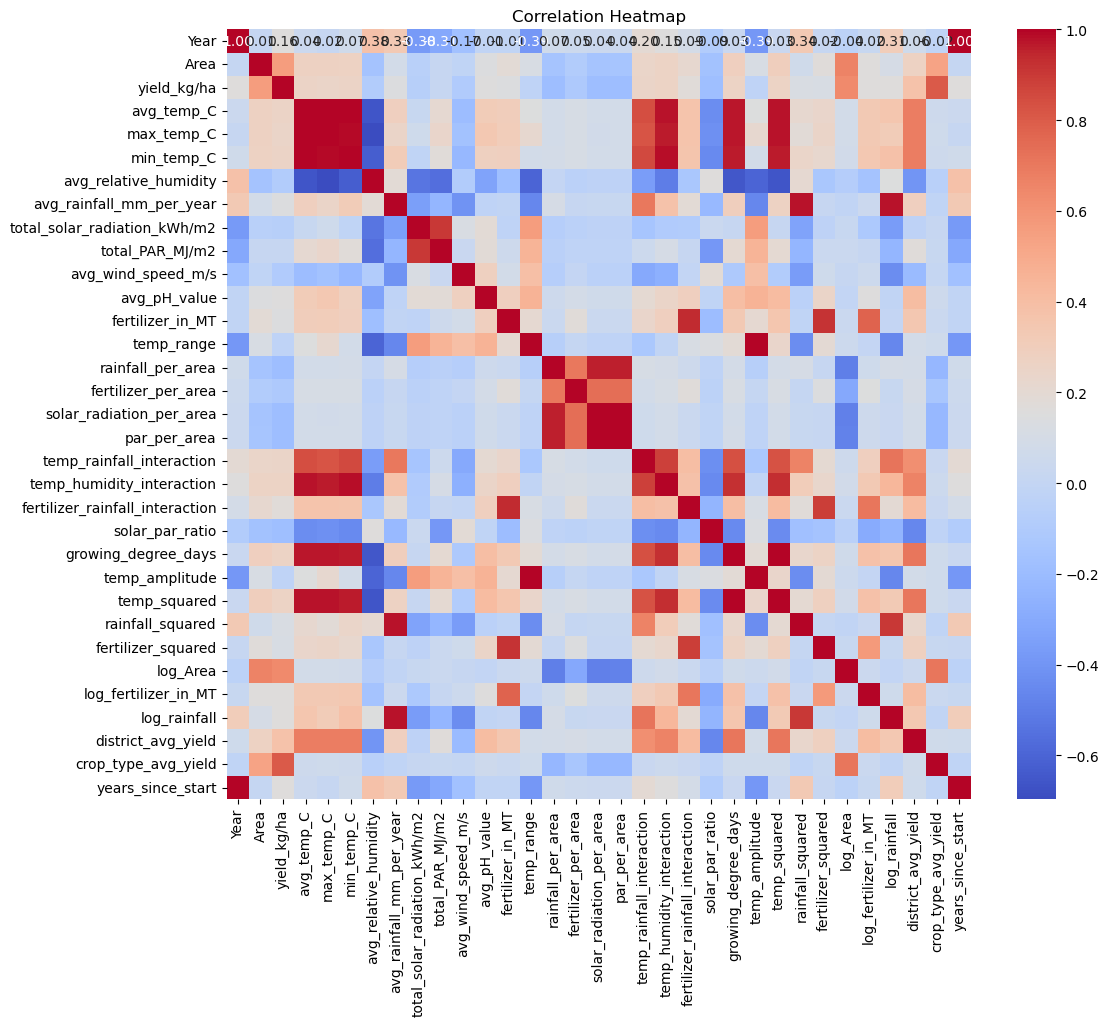

Correlation heatmap saved.


In [19]:
numeric_cols = crop_data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(crop_data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig("plots/corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Correlation heatmap saved.")

<h3>Per-crop scatter plots</h3>

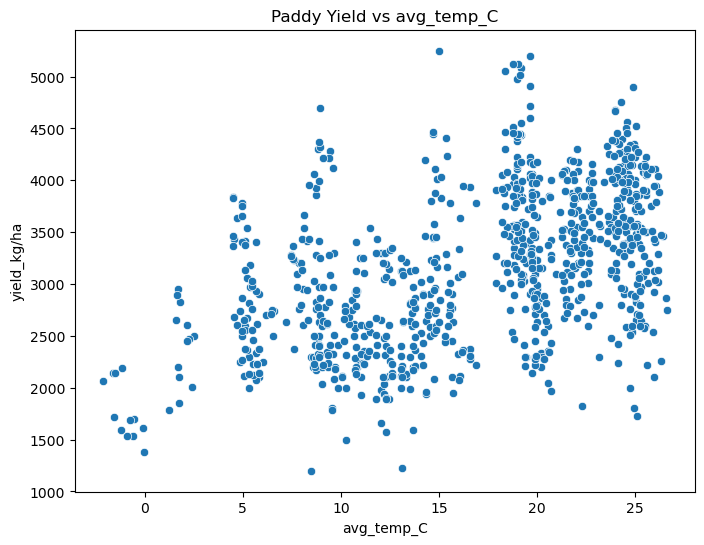

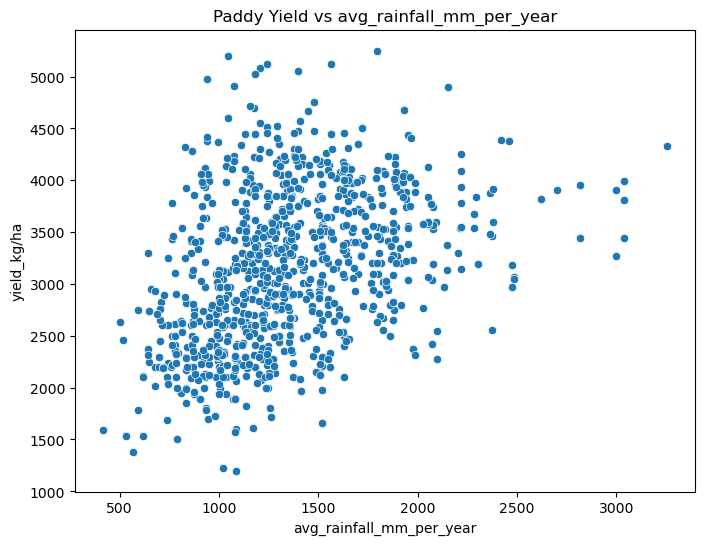

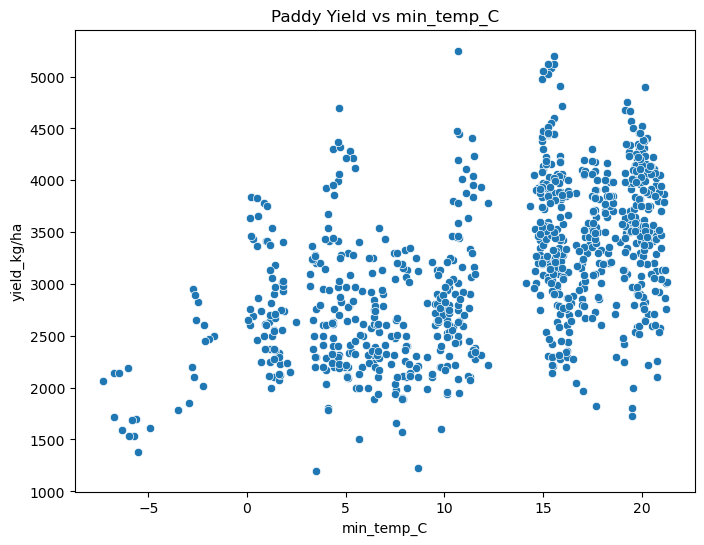

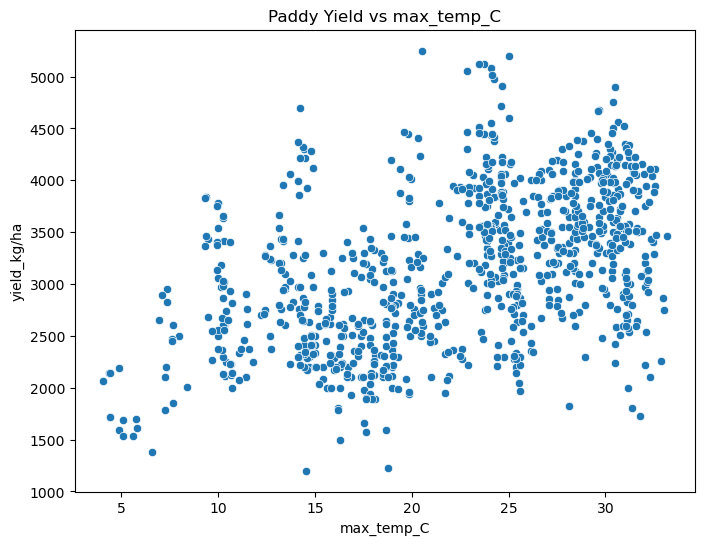

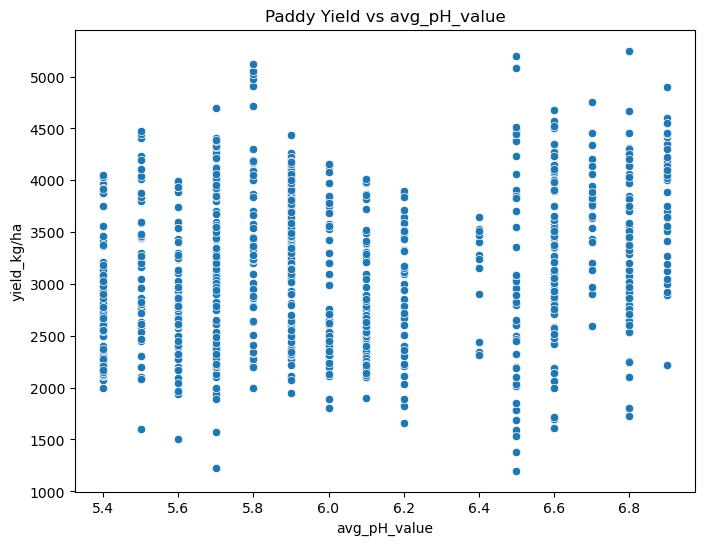

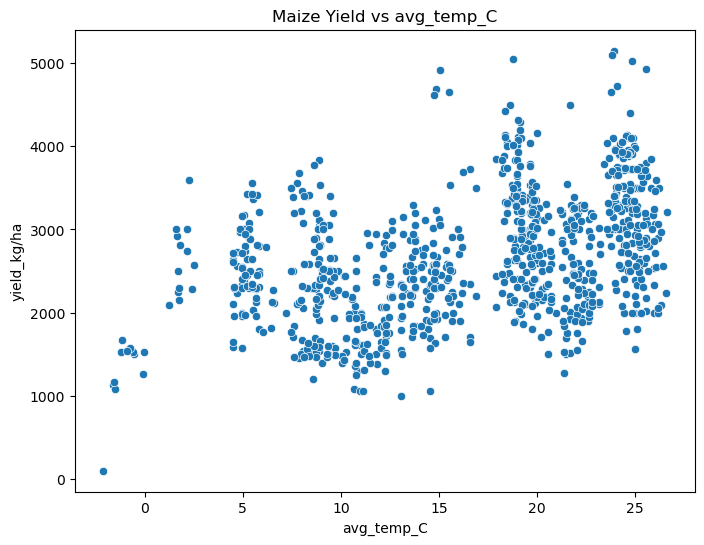

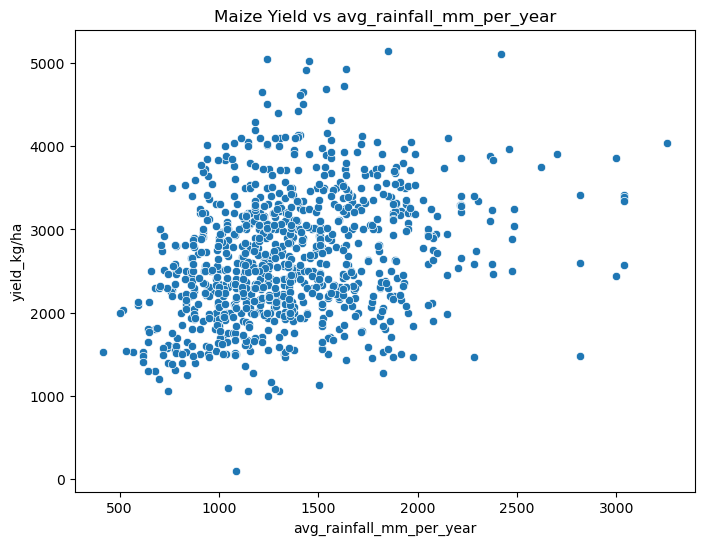

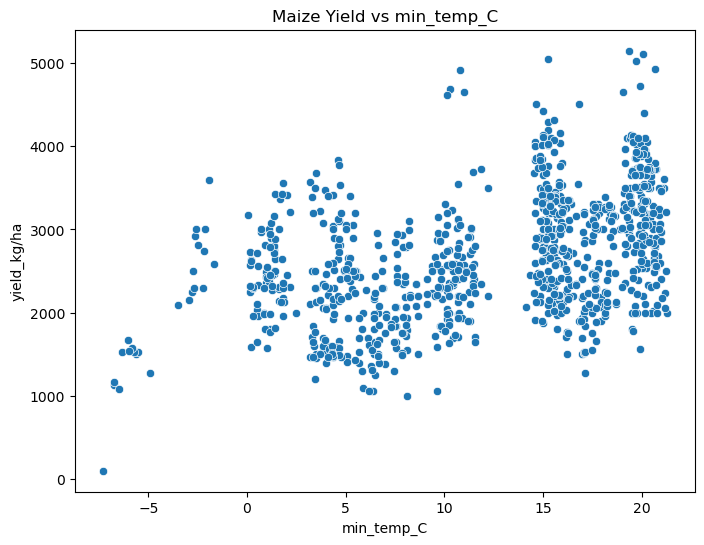

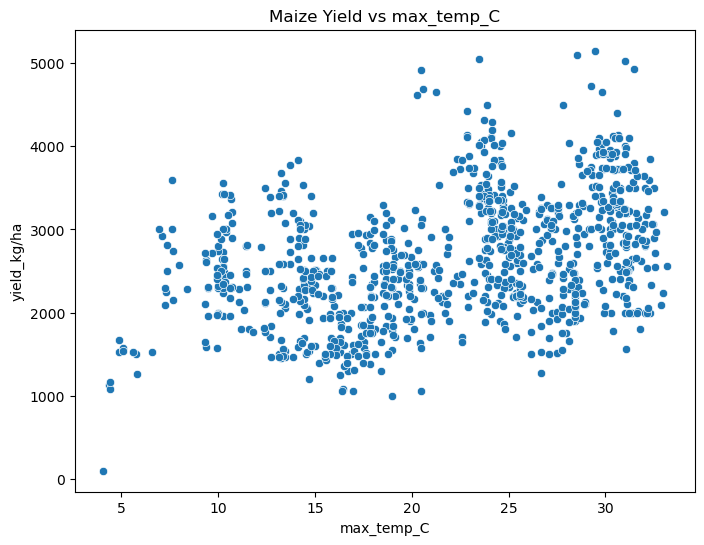

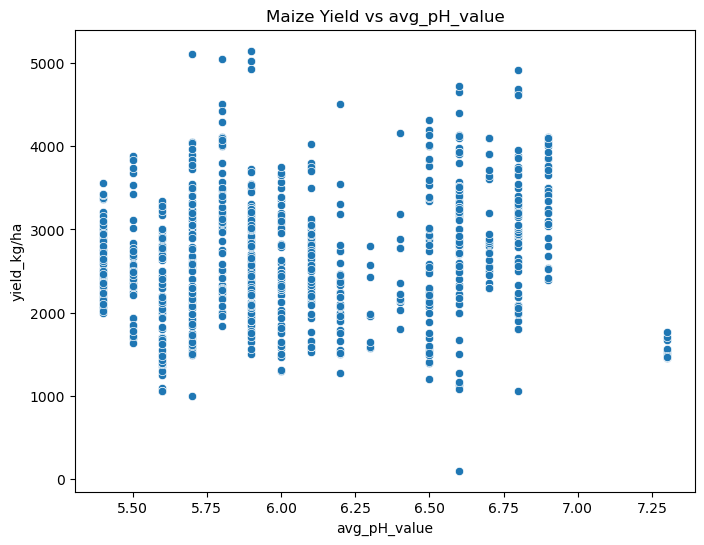

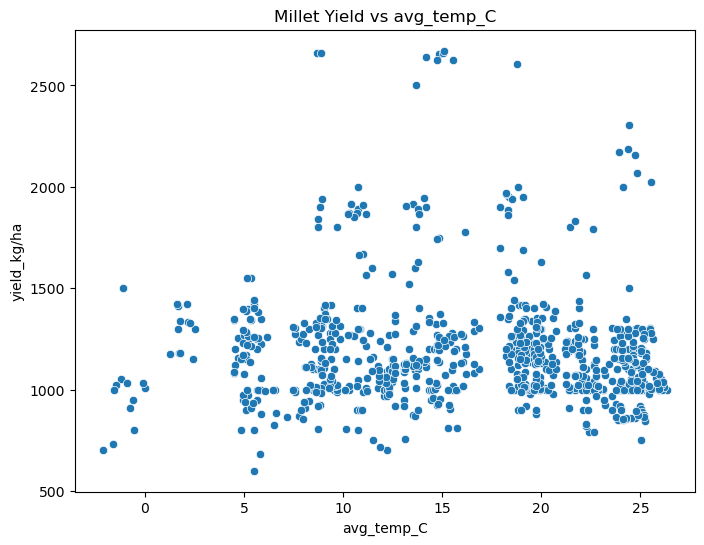

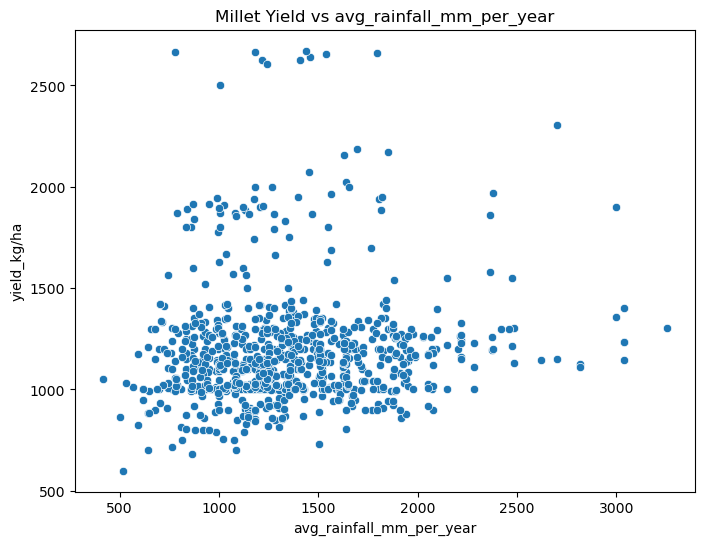

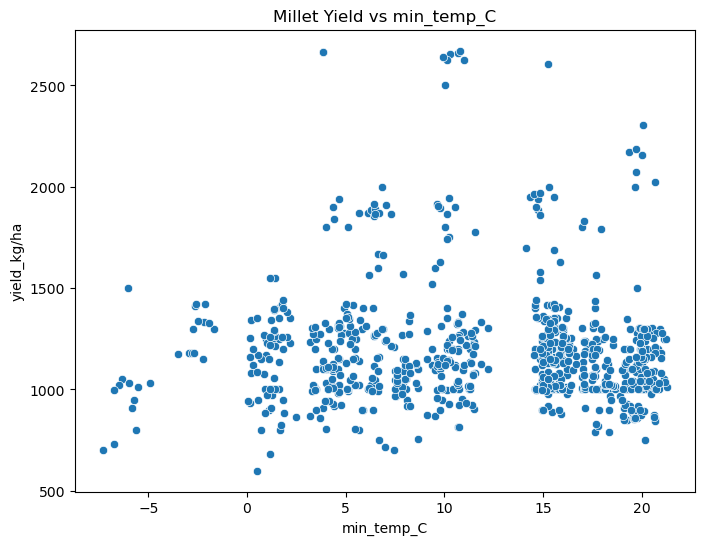

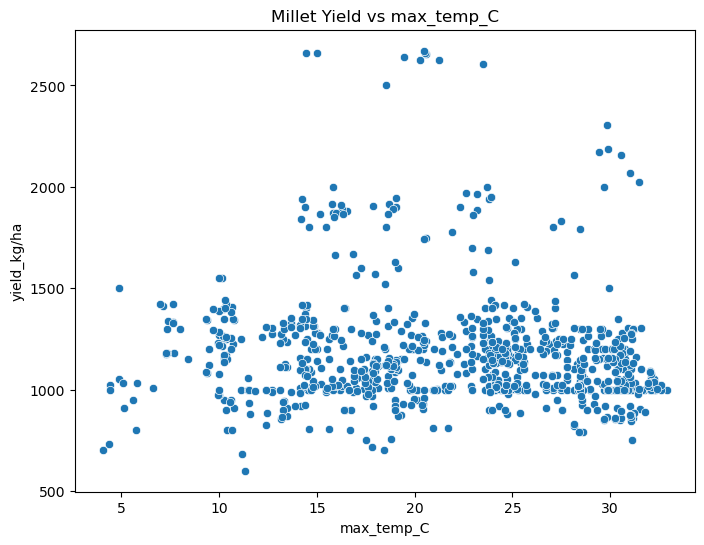

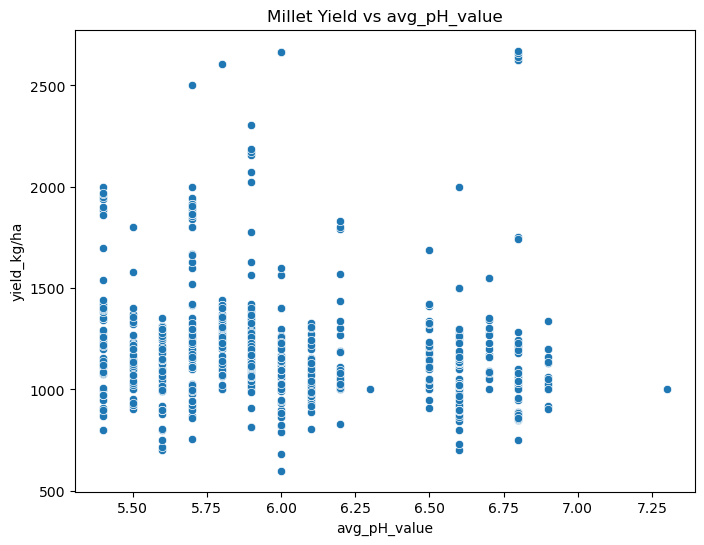

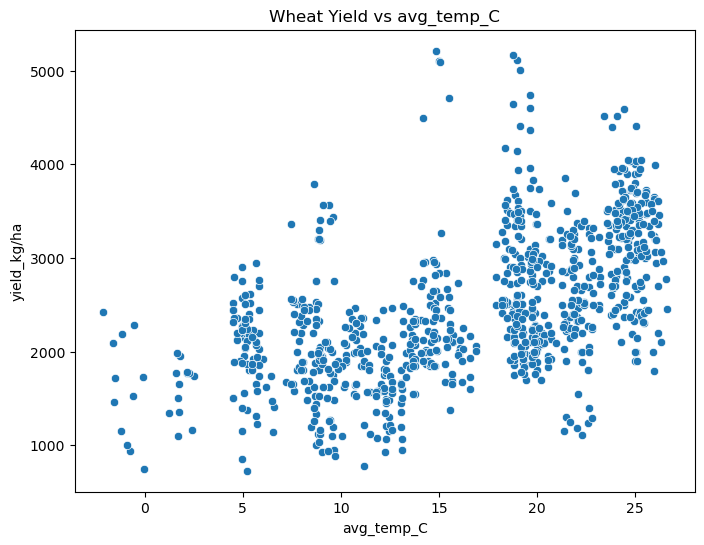

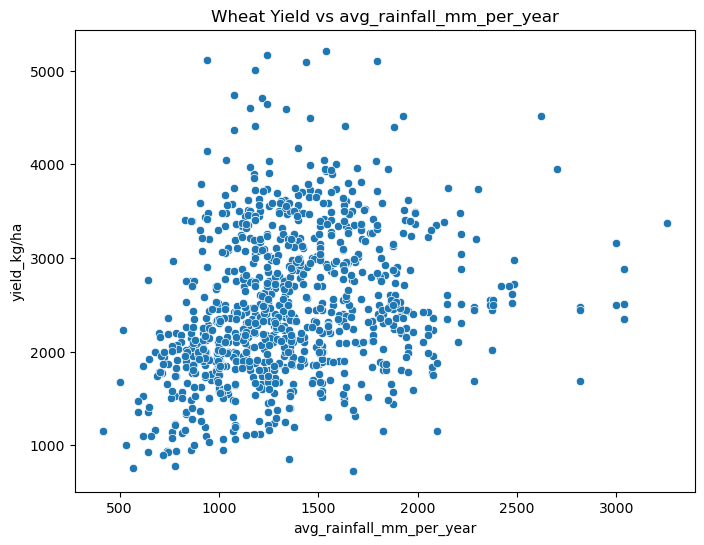

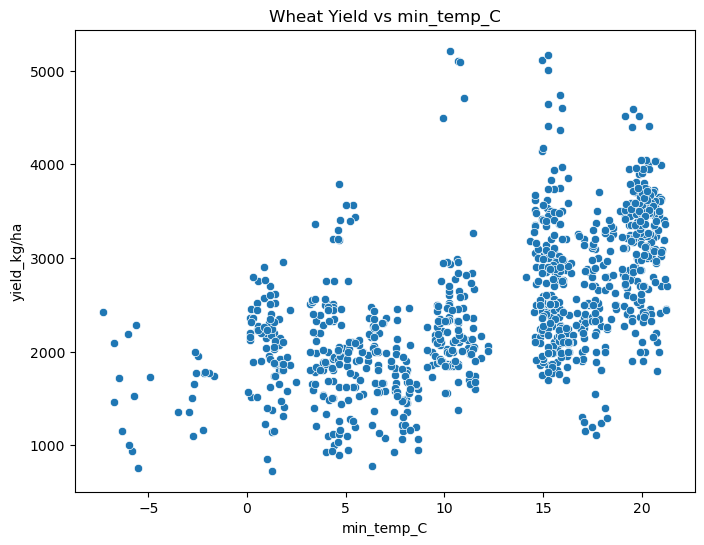

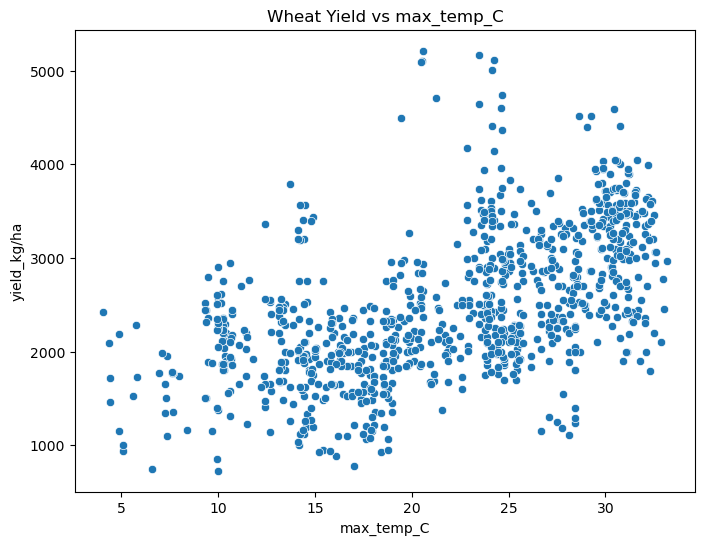

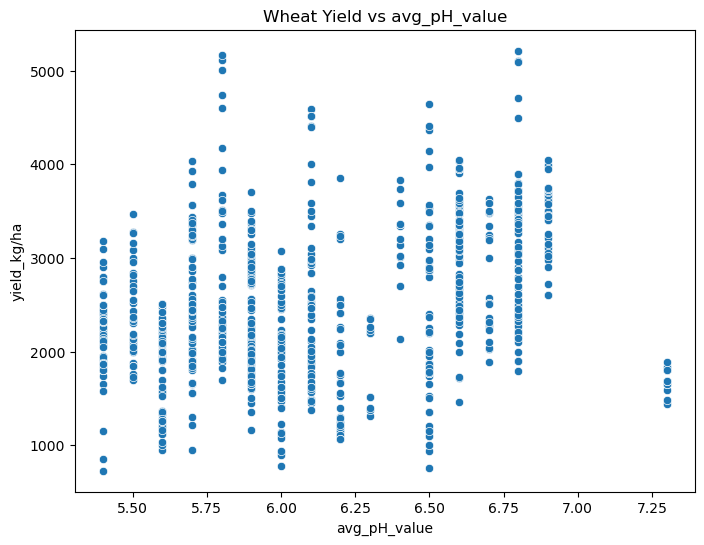

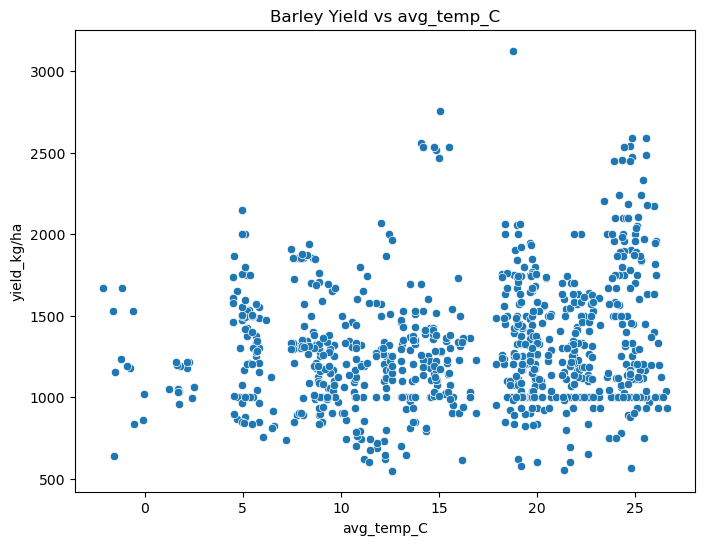

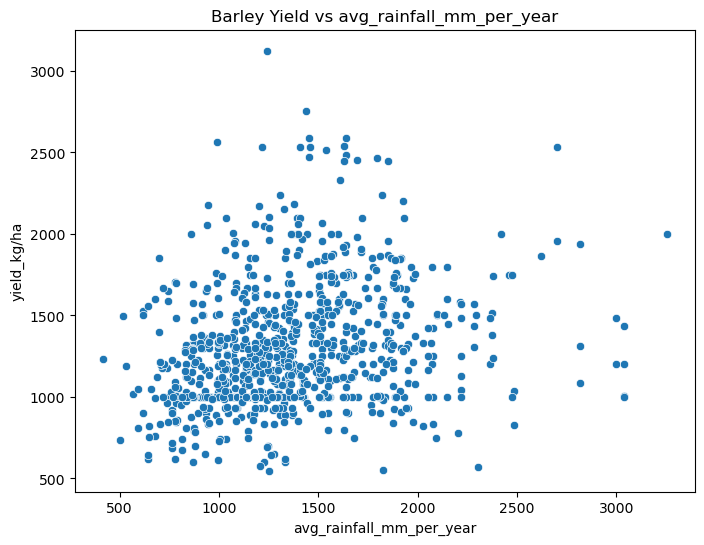

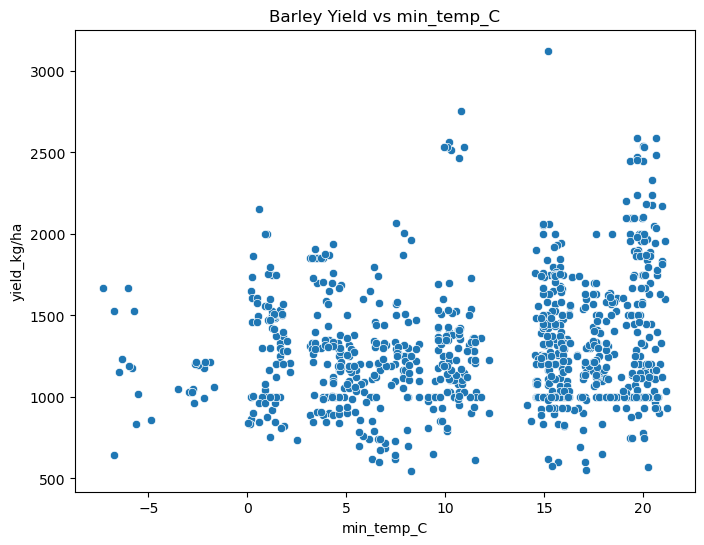

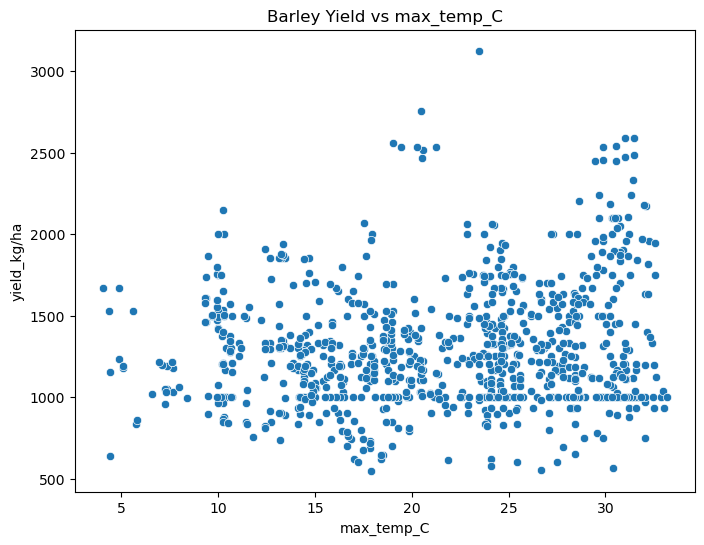

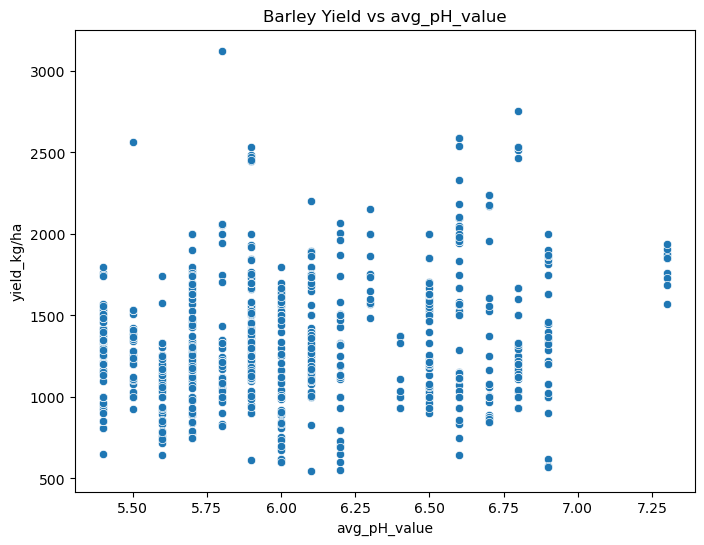

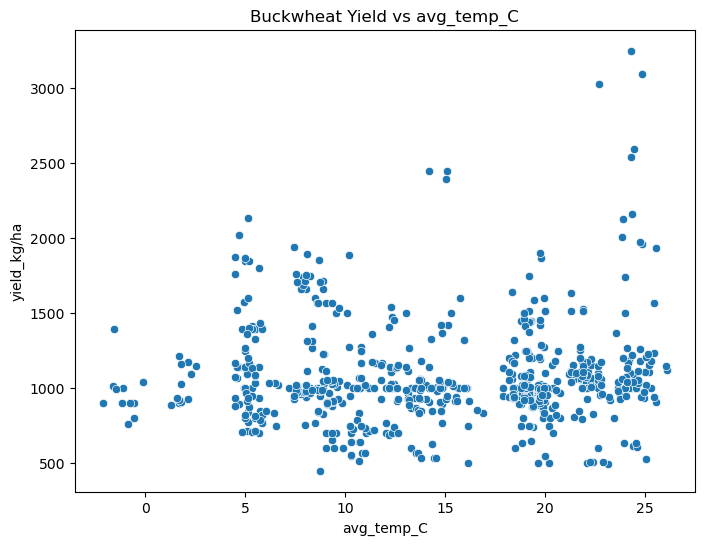

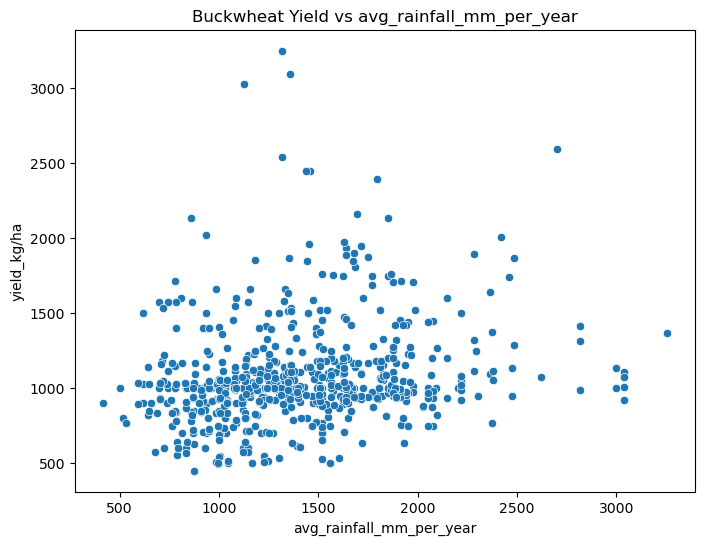

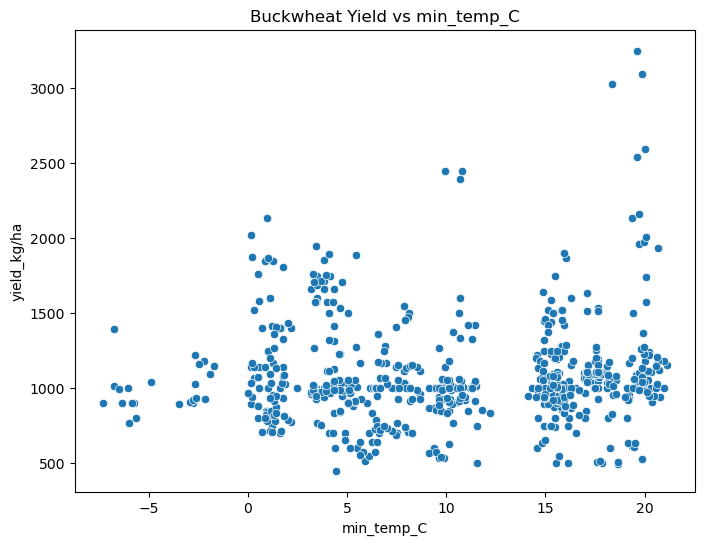

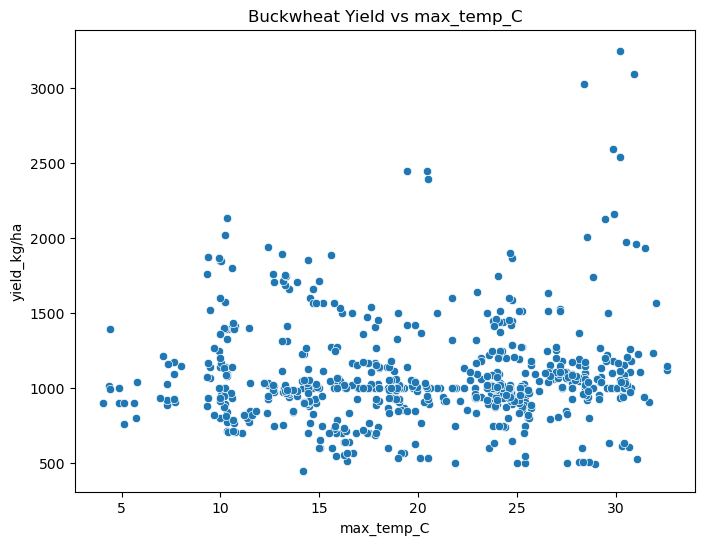

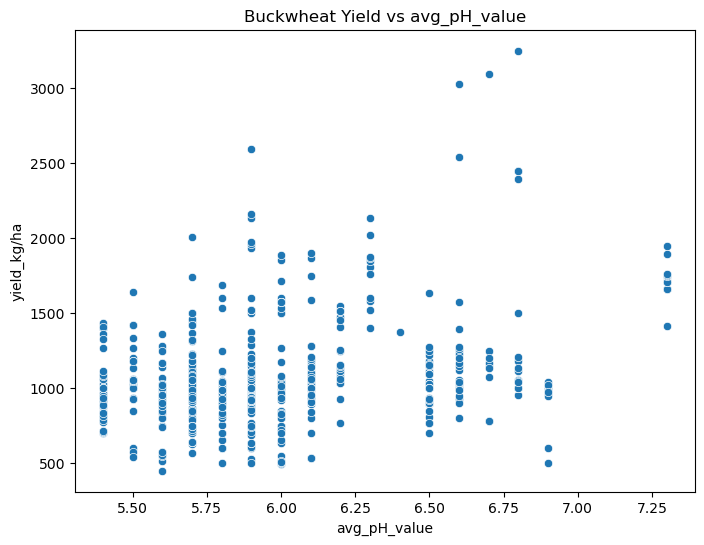

Per-crop scatter plots saved.


In [20]:
crop_types = crop_data['crop_type'].unique()
for crop in crop_types:
    df_crop = crop_data[crop_data['crop_type'] == crop]
    for col in ['avg_temp_C', 'avg_rainfall_mm_per_year', 'min_temp_C', 'max_temp_C', 'avg_pH_value']:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=df_crop[col], y=df_crop['yield_kg/ha'])
        plt.title(f'{crop} Yield vs {col}')
        plt.savefig(f"plots/{crop}_vs_{col}.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
print("Per-crop scatter plots saved.")

<h3>Target Variable Transformation</h3>

In [21]:
print("Applying target transformation...")

from sklearn.preprocessing import QuantileTransformer

# Transform target variable to handle potential skewness
target_transformer = QuantileTransformer(output_distribution='normal', random_state=42)
y_transformed = target_transformer.fit_transform(y.values.reshape(-1, 1)).flatten()

print("Target transformation completed.")

Applying target transformation...
Target transformation completed.


<h3>Separate features (X) and target (y)</h3>

In [22]:
X = crop_data.drop('yield_kg/ha', axis=1)  # All columns except target
y = crop_data['yield_kg/ha']  # Target column

<h3> Split data into train (70%), validation (10%), test (20%)</h3>

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  # First split: train+val vs test
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, shuffle=False)  # Second split: train vs val

<h3>Display the shape of training, testing and validation dataset</h3>

In [24]:
print("Train shape:", X_train.shape)  # Show train size
print("Validation shape:", X_val.shape)  # Show val size
print("Test shape:", X_test.shape)  # Show test size

Train shape: (3578, 34)
Validation shape: (512, 34)
Test shape: (1023, 34)


<h3>Identify categorical and numerical columns</h3>

In [25]:
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()  # Categorical (text) columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()  # Numerical columns
print("Categorical columns:", categorical_cols)  # Show categorical
print("Numerical columns:", numerical_cols)  # Show numerical

Categorical columns: ['Districts', 'crop_type']
Numerical columns: ['Year', 'Area', 'avg_temp_C', 'max_temp_C', 'min_temp_C', 'avg_relative_humidity', 'avg_rainfall_mm_per_year', 'total_solar_radiation_kWh/m2', 'total_PAR_MJ/m2', 'avg_wind_speed_m/s', 'avg_pH_value', 'fertilizer_in_MT', 'temp_range', 'rainfall_per_area', 'fertilizer_per_area', 'solar_radiation_per_area', 'par_per_area', 'temp_rainfall_interaction', 'temp_humidity_interaction', 'fertilizer_rainfall_interaction', 'solar_par_ratio', 'growing_degree_days', 'temp_amplitude', 'temp_squared', 'rainfall_squared', 'fertilizer_squared', 'log_Area', 'log_fertilizer_in_MT', 'log_rainfall', 'district_avg_yield', 'crop_type_avg_yield', 'years_since_start']


<h3>One-Hot Encoding (convert categorical to numbers)</h3>

In [26]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # Encoder setup
encoder.fit(X_train[categorical_cols])  # Fit on train

X_train_encoded = encoder.transform(X_train[categorical_cols])  # Encode train
X_val_encoded = encoder.transform(X_val[categorical_cols])  # Encode val
X_test_encoded = encoder.transform(X_test[categorical_cols])  # Encode test

encoded_cat_cols = encoder.get_feature_names_out(categorical_cols)  # New column names

<h3>Convert encoded to DataFrames</h3>

In [27]:
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_cat_cols, index=X_train.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_cat_cols, index=X_val.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_cat_cols, index=X_test.index)

<h3>Drop original categorical columns and combine with encoded</h3>

In [28]:
X_train_num = X_train.drop(columns=categorical_cols, axis=1)
X_val_num = X_val.drop(columns=categorical_cols, axis=1)
X_test_num = X_test.drop(columns=categorical_cols, axis=1)

X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)  # Final train
X_val_final = pd.concat([X_val_num, X_val_encoded_df], axis=1)  # Final val
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)  # Final test

<h3>Handle multicollinearity with VIF</h3>

In [29]:
def calculate_vif(df):
    vif = pd.DataFrame()
    vif["Feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

vif_df = calculate_vif(X_train_final[numerical_cols])
high_vif = vif_df[vif_df['VIF'] > 5]['Feature'].tolist()
X_train_final.drop(columns=high_vif, inplace=True, errors='ignore')
X_val_final.drop(columns=high_vif, inplace=True, errors='ignore')
X_test_final.drop(columns=high_vif, inplace=True, errors='ignore')
numerical_cols = [col for col in numerical_cols if col not in high_vif]
print("Dropped high VIF features:", high_vif)

c:\Users\HP\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropped high VIF features: ['Year', 'avg_temp_C', 'max_temp_C', 'min_temp_C', 'avg_relative_humidity', 'avg_rainfall_mm_per_year', 'total_solar_radiation_kWh/m2', 'total_PAR_MJ/m2', 'fertilizer_in_MT', 'temp_range', 'rainfall_per_area', 'solar_radiation_per_area', 'par_per_area', 'temp_rainfall_interaction', 'temp_humidity_interaction', 'fertilizer_rainfall_interaction', 'solar_par_ratio', 'growing_degree_days', 'temp_amplitude', 'temp_squared', 'rainfall_squared', 'fertilizer_squared', 'log_rainfall', 'years_since_start']


<h3>Feature Scaling (normalize numerical features)</h3>

In [30]:
scaler = StandardScaler()  # Scaler setup
X_train_final[numerical_cols] = scaler.fit_transform(X_train_final[numerical_cols])  # Fit and transform train
X_val_final[numerical_cols] = scaler.transform(X_val_final[numerical_cols])  # Transform val
X_test_final[numerical_cols] = scaler.transform(X_test_final[numerical_cols])  # Transform test

<h3>Feature Selection with SelectKBest</h3>

In [31]:
selector = SelectKBest(score_func=f_regression, k=20)
X_train_final = selector.fit_transform(X_train_final, y_train)
X_val_final = selector.transform(X_val_final)
X_test_final = selector.transform(X_test_final)
print("Selected top 20 features.")

print("Data preprocessing complete.")  # Preprocessing done

Selected top 20 features.
Data preprocessing complete.


<h3>Define models and their hyperparameters (expanded)</h3>

In [32]:
tuned_models = {
    "Linear Regression": {'model': LinearRegression(), 'params': {}},
    "Ridge": {'model': Ridge(random_state=42), 'params': {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}},
    "Lasso": {'model': Lasso(random_state=42, max_iter=10000), 'params': {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}},
    "Decision Tree": {'model': DecisionTreeRegressor(random_state=42), 'params': {'max_depth': [3, 5, 10, None], 'min_samples_split': [2, 5, 10]}},
    "Random Forest": {'model': RandomForestRegressor(random_state=42), 'params': {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None], 'min_samples_split': [2, 5]}},
    "Gradient Boosting": {'model': GradientBoostingRegressor(random_state=42), 'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}},
    "SVR": {'model': SVR(), 'params': {'C': [1.0, 10.0, 100.0], 'epsilon': [0.1, 0.5, 1.0]}},
    "XGBoost": {'model': XGBRegressor(random_state=42, verbosity=0), 'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}},
    "LightGBM": {'model': LGBMRegressor(random_state=42, verbose=-1), 'params': {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, -1]}},
    "CatBoost": {'model': CatBoostRegressor(random_state=42, verbose=0), 'params': {'iterations': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'depth': [4, 6, 8]}}
}

<h3>Add Stacking Model

In [33]:
estimators = [
    ('rf', RandomForestRegressor(random_state=42)),
    ('xgb', XGBRegressor(random_state=42)),
    ('lgbm', LGBMRegressor(random_state=42))
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=Ridge())
tuned_models["Stacking"] = {'model': stacking_model, 'params': {}}

<h3>Function to evaluate a model</h3>

In [34]:
def evaluate_model(name, model, X_val, y_val):
    y_pred = model.predict(X_val)  # Predict on val
    mae = mean_absolute_error(y_val, y_pred)  # Mean Absolute Error
    mse = mean_squared_error(y_val, y_pred)  # Mean Squared Error
    rmse = np.sqrt(mse)  # Root Mean Squared Error
    r2 = r2_score(y_val, y_pred)  # R2 Score
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}  # Return metrics

<h3>Train, tune, and evaluate all models</h3>

In [35]:
results = []  # List to store results
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # For cross-validation
for name, info in tuned_models.items():
    print(f"Tuning and evaluating {name}...")  # Progress message
    model = info['model']  # Get model
    params = info['params']  # Get params
    if params:
        grid = GridSearchCV(model, params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)  # Increased cv=5
        grid.fit(X_train_final, y_train)  # Fit tuner
        best_model = grid.best_estimator_  # Best tuned model
        best_params = grid.best_params_  # Best params
    else:
        best_model = model.fit(X_train_final, y_train)  # Fit default model
        best_params = "Default"  # No tuning
    
    metrics = evaluate_model(name, best_model, X_val_final, y_val)  # Evaluate
    metrics["Best Params"] = best_params  # Add params
    results.append(metrics)  # Add to results

Tuning and evaluating Linear Regression...
Tuning and evaluating Ridge...
Tuning and evaluating Lasso...
Tuning and evaluating Decision Tree...
Tuning and evaluating Random Forest...
Tuning and evaluating Gradient Boosting...
Tuning and evaluating SVR...
Tuning and evaluating XGBoost...
Tuning and evaluating LightGBM...
Tuning and evaluating CatBoost...
Tuning and evaluating Stacking...


<h3>Create and save results table</h3>

In [36]:
results_df = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)  # Sort by best R2
print("Model Results:")
print(results_df)  # Show in console
results_df.to_csv("../models/model_results.csv", index=False)  # Save to CSV
print("Results saved to model_results.csv")

Model Results:
                Model         MAE            MSE        RMSE  R2 Score  \
10           Stacking  242.112749  110895.298538  333.009457  0.907124   
4       Random Forest  244.674228  111975.085849  334.626786  0.906219   
9            CatBoost  266.424387  123302.853699  351.145061  0.896732   
8            LightGBM  271.366096  130915.352721  361.822267  0.890356   
7             XGBoost  272.126316  131085.685432  362.057572  0.890214   
5   Gradient Boosting  277.409925  132742.070820  364.337853  0.888827   
3       Decision Tree  295.050852  165667.407095  407.022613  0.861251   
6                 SVR  387.598647  269070.101565  518.719675  0.774650   
0   Linear Regression  402.567680  278480.602338  527.712613  0.766768   
1               Ridge  402.751645  279080.483900  528.280687  0.766266   
2               Lasso  402.901158  279290.684835  528.479597  0.766090   

                                          Best Params  
10                                      

<h3>Get the best model</h3>

In [37]:
best_row = results_df.iloc[0]  # First row is best
best_name = best_row['Model']  # Best model name
best_model_info = tuned_models[best_name]  # Get info
best_model = best_model_info['model']  # Base model
if best_model_info['params']:
    # Refit with best params
    grid = GridSearchCV(best_model, best_model_info['params'], cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train_final, y_train)
    best_model = grid.best_estimator_
else:
    best_model = best_model.fit(X_train_final, y_train)  # Refit

<h3>Save best model</h3>

In [38]:
joblib.dump(best_model, '../models/best_model.pkl')
print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl


<h3>Predict on validation set for plots</h3>

In [39]:
y_pred_val = best_model.predict(X_val_final)  # Predictions

<h3>Predict the yield value using user inputs</h3>

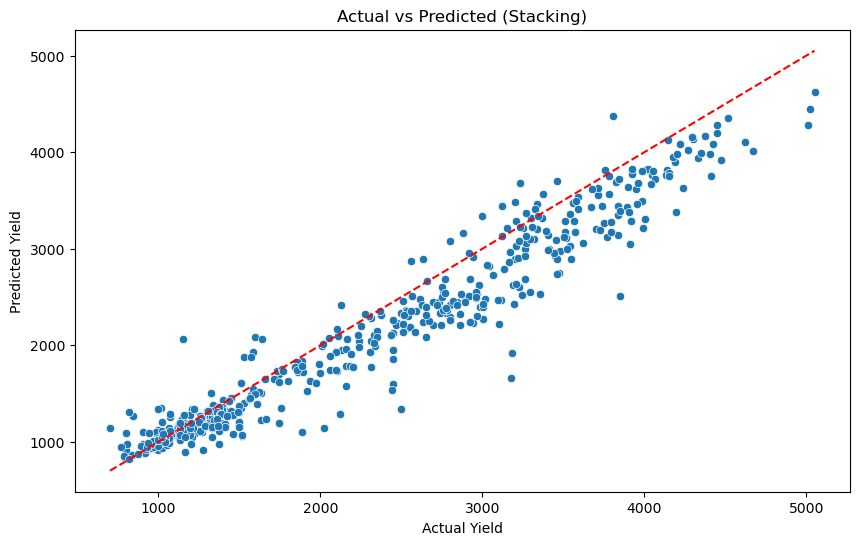

Actual vs Predicted plot saved.


In [40]:
plt.figure(figsize=(10, 6))  # Figure size
sns.scatterplot(x=y_val, y=y_pred_val)  # Scatter plot
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # Perfect line
plt.xlabel("Actual Yield")  # X label
plt.ylabel("Predicted Yield")  # Y label
plt.title(f"Actual vs Predicted ({best_name})")  # Title
plt.savefig("plots/actual_vs_predicted.png", dpi=300, bbox_inches="tight")  # Save
plt.show()  # Show
print("Actual vs Predicted plot saved.")

<h3>Plot Residuals</h3>

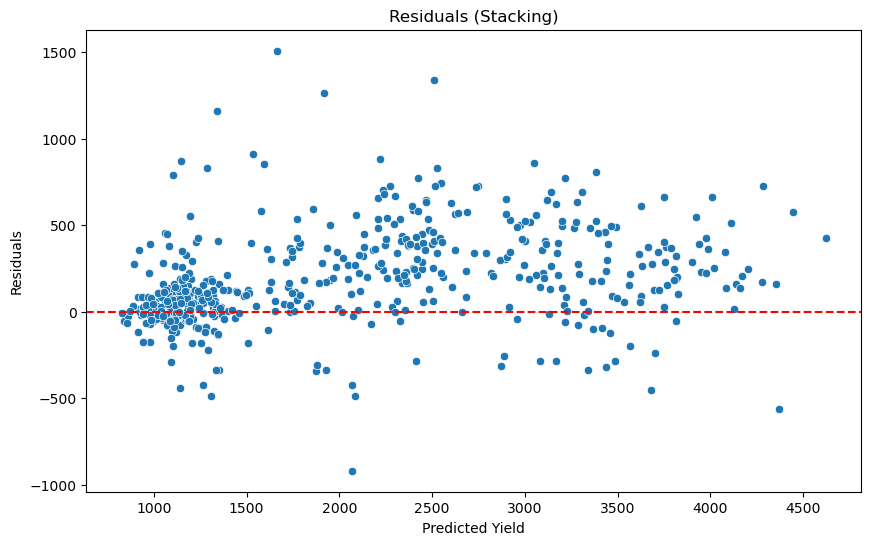

Residuals plot saved.


In [41]:
residuals = y_val - y_pred_val  # Calculate residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_val, y=residuals)  # Scatter
plt.axhline(0, color='r', linestyle='--')  # Zero line
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title(f"Residuals ({best_name})")
plt.savefig("plots/residuals.png", dpi=300, bbox_inches="tight")
plt.show()
print("Residuals plot saved.")

<h3>Plot Feature Importances (if model supports it)</h3>

In [42]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({'Feature': selector.get_feature_names_out(), 'Importance': best_model.feature_importances_}).sort_values('Importance', ascending=False)  # Importances DF
    print("Top 10 Feature Importances:")
    print(importances.head(10))  # Show top 10
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importances.head(10))  # Bar plot
    plt.title(f"Top 10 Features ({best_name})")
    plt.savefig("plots/feature_importances.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Feature Importances plot saved.")
else:
    print("No feature importances for this model.")

No feature importances for this model.


<h3>Final evaluation on test set</h3>

In [43]:
y_pred_test = best_model.predict(X_test_final)  # Predict on test
test_r2 = r2_score(y_test, y_pred_test)  # Test R2
print(f"Test R2 Score for {best_name}: {test_r2}")  # Show test score

print("Training complete. Check 'model_results.csv', 'data_insights.csv', and plots folder.")

Test R2 Score for Stacking: 0.8350005546923798
Training complete. Check 'model_results.csv', 'data_insights.csv', and plots folder.
